# Composable Models: Terms → Operators → Cycles

somax models plug into the [pipekit](https://github.com/jejjohnson/pipekit)
ecosystem along three seams that build on each other. This tutorial walks
the whole path end to end:

1. **Terms** — a model's right-hand side as a *sum of composable physics
   kernels*, with per-term `explicit`/`implicit` tags for IMEX integration.
2. **Operators** — wrapping a built model as a `pipekit.Operator`: a
   one-step pipeline stage that satisfies `pipekit_cycle.ForwardModel` and
   (for flat-config models) round-trips through `pipekit.serial`.
3. **Cycles** — driving the stepping loop with `pipekit_cycle.Cycle`,
   threading state and collecting a trajectory.

Everything here needs the `sim` dependency group (`uv sync --group sim`),
which carries pipekit.
somax's *core* never imports pipekit — models satisfy the protocols
structurally.

In [1]:
from __future__ import annotations

import jax.numpy as jnp
import matplotlib.pyplot as plt
from pipekit import dumps, loads
from pipekit_cycle import Cycle, ForwardModel

from somax._src.models.swm.linear_2d import LinearSW2DState
from somax._src.models.swm.linear_swm_terms import LinearSWM2DTermModel
from somax.operators import Burgers2DOp, SomaxModelOp

## 1. A model as a sum of term-kernels

The linear shallow water right-hand side decomposes into four distinct
physics kernels — a gravity-wave (pressure) term, Coriolis, lateral
diffusion, and bottom drag — that compose with `+`:

$$
\texttt{rhs} = \underbrace{\texttt{gravity\_wave}}_{\text{fast, stiff}}
  + \texttt{coriolis}
  + \nu \cdot \underbrace{\texttt{diffusion}}_{\text{stiff}}
  + (-\kappa) \cdot \texttt{drag}
$$

The differentiable parameters ($\nu$, $\kappa$) enter as `Scaled`
coefficients (JAX leaves), so a loss can be differentiated straight
through them.

In [2]:
model = LinearSWM2DTermModel.create(
    nx=64,
    ny=64,
    Lx=2_000e3,
    Ly=2_000e3,
    f0=1e-4,
    beta=2e-11,
    H0=100.0,
    lateral_viscosity=200.0,
    bottom_drag=1e-7,
)

# The assembled right-hand side is a Sum of four term-kernels:
for term in model.terms.terms:
    print(type(term).__name__, "->", repr(term))

print("\nviscosity nu read back from the tree:", float(model.nu))
print("bottom drag kappa read back from the tree:", float(model.kappa))

LinearSWMGravityWave -> LinearSWMGravityWave(
  diff=Difference2D(
    grid=CartesianGrid2D(
      Nx=66, Ny=66, Lx=2000000.0, Ly=2000000.0, dx=31250.0, dy=31250.0
    )
  ),
  g=9.81,
  H0=100.0
)
LinearSWMCoriolis -> LinearSWMCoriolis(
  coriolis=Coriolis2D(
    grid=CartesianGrid2D(
      Nx=66, Ny=66, Lx=2000000.0, Ly=2000000.0, dx=31250.0, dy=31250.0
    ),
    mask=None,
    interp=Interpolation2D(
      grid=CartesianGrid2D(
        Nx=66, Ny=66, Lx=2000000.0, Ly=2000000.0, dx=31250.0, dy=31250.0
      )
    )
  ),
  f_field=weak_f32[66,66]
)
Scaled -> Scaled(
  term=LinearSWMDiffusion(
    diff=Difference2D(
      grid=CartesianGrid2D(
        Nx=66, Ny=66, Lx=2000000.0, Ly=2000000.0, dx=31250.0, dy=31250.0
      )
    )
  ),
  coeff=weak_f32[]
)
Scaled -> Scaled(term=LinearSWMDrag(), coeff=weak_f32[])

viscosity nu read back from the tree: 200.0
bottom drag kappa read back from the tree: 1.0000000116860974e-07


## 2. IMEX — tag stiff terms implicit

Because each kernel carries an integration `kind`, a stiff term can be
routed to the implicit stage of a splitting (IMEX) solver. With the
default (all explicit) the whole RHS lowers to a single `diffrax.ODETerm`;
with `imex=True` the diffusion term is tagged implicit and the RHS lowers
to a `diffrax.MultiTerm` that an IMEX solver (e.g. `KenCarp3`) integrates
with the stiff Laplacian handled implicitly.

In [3]:
explicit_model = LinearSWM2DTermModel.create(nx=32, ny=32, lateral_viscosity=200.0)
imex_model = LinearSWM2DTermModel.create(
    nx=32, ny=32, lateral_viscosity=200.0, imex=True
)

print("explicit build_terms():", type(explicit_model.build_terms()).__name__)
print("imex     build_terms():", type(imex_model.build_terms()).__name__)

explicit build_terms(): ODETerm
imex     build_terms(): MultiTerm


## 3. Wrap a built model as a pipekit Operator

`SomaxModelOp` turns *any* built somax model into a `pipekit.Operator`: a
one-step stage (`op(state) -> next_state`) that also satisfies the
`pipekit_cycle.ForwardModel` protocol (`step` / `dt` / `state_signature`).

In [4]:
op = SomaxModelOp(model, dt=90.0)
print("isinstance(op, ForwardModel):", isinstance(op, ForwardModel))
print("wrapped model:", type(op.model).__name__)

isinstance(op, ForwardModel): True
wrapped model: LinearSWM2DTermModel


## 4. Flat-config models round-trip through `pipekit.serial`

A built model is an `eqx.Module` (grids, operators, term trees) — not JSON
primitives — so the general wrapper above is *not* serializable. Models
whose construction is a **flat primitive recipe** expose a dedicated
Operator (e.g. `Burgers2DOp`) whose config is all primitives, so
`dumps`/`loads` round-trips the build recipe faithfully.

In [5]:
burgers = Burgers2DOp(nx=32, ny=32, nu=0.05, dt=1e-3, imex=False)
blob = dumps(burgers)
print("serialized config:", blob)

restored = loads(blob)
print("round-trip matches:", restored.get_config() == burgers.get_config())

serialized config: {"class": "Burgers2DOp", "config": {"Lx": 2.0, "Ly": 2.0, "dt": 0.001, "imex": false, "method": "upwind1", "nu": 0.05, "nx": 32, "ny": 32}, "module": "somax._src.operators"}
round-trip matches: True


## 5. Drive the model with `pipekit_cycle.Cycle`

`Cycle` applies the step operator `n_steps` times, threading state and
(with `save_history=True`) collecting the trajectory. We seed a Gaussian
height bump and watch gravity waves radiate outward under rotation — a
geostrophic-adjustment problem. The gravity-wave *term* from step 1 is
exactly what drives this.

In [6]:
grid = model.grid
x = jnp.arange(grid.Nx) * grid.dx
y = jnp.arange(grid.Ny) * grid.dy
X, Y = jnp.meshgrid(x, y)
cx, cy = grid.Nx * grid.dx / 2, grid.Ny * grid.dy / 2
sigma = grid.Nx * grid.dx / 12
h0 = jnp.exp(-0.5 * (((X - cx) / sigma) ** 2 + ((Y - cy) / sigma) ** 2))
state0 = LinearSW2DState(h=h0, u=jnp.zeros_like(h0), v=jnp.zeros_like(h0))

cycle = Cycle(step_op=op, n_steps=120, save_history=True, history_stride=20)
final_state, _ = cycle(state0, None)
print("steps recorded in history:", len(cycle.history))

steps recorded in history: 6


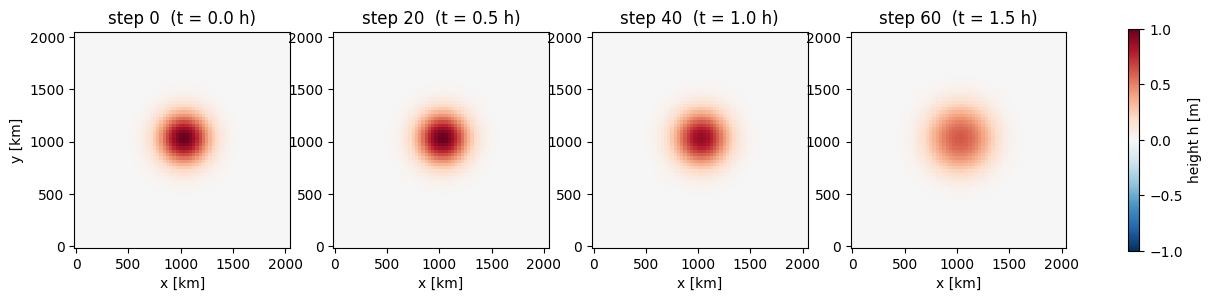

In [7]:
# Plot the initial bump and a few snapshots from the cycle history.
snapshots = [(0, state0)] + [
    (((i + 1) * cycle.history_stride), carrier)
    for i, (carrier, _state) in enumerate(cycle.history[:3])
]
fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.6))
vmax = float(jnp.max(jnp.abs(h0)))
for ax, (step, st) in zip(axes, snapshots, strict=True):
    im = ax.pcolormesh(
        X / 1e3, Y / 1e3, st.h, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto"
    )
    ax.set_title(f"step {step}  (t = {step * op.dt / 3600:.1f} h)")
    ax.set_xlabel("x [km]")
    ax.set_aspect("equal")
axes[0].set_ylabel("y [km]")
fig.colorbar(im, ax=axes, shrink=0.8, label="height h [m]")
plt.show()

## 6. The `scenario x model` registry, end to end

`SomaxModelOp.from_registry` builds *any* compatible scenario x model pair
through the dispatcher and hands back `(op, state0)` ready for `Cycle`.
This is the full "what we simulate (scenario) x how we simulate it
(model)" composition, wrapped as a pipekit Operator.

In [8]:
reg_op, reg_state0 = SomaxModelOp.from_registry(
    "double_gyre",
    "linear_swm",
    dt=60.0,
    scenario_params={"grid": {"nx": 16, "ny": 16}},
    model_params={"params": {"lateral_viscosity": 100.0, "bottom_drag": 1e-6}},
)
reg_final, _ = Cycle(step_op=reg_op, n_steps=10)(reg_state0, None)
print("built:", type(reg_op.model).__name__)
print("forward-integrated 10 steps; finite:", bool(jnp.all(jnp.isfinite(reg_final.h))))

# Operators compose like any pipekit stage — ``op | op`` is two steps.
two_steps = (reg_op | reg_op)(reg_state0)
print("op | op == two steps:", bool(jnp.all(jnp.isfinite(two_steps.h))))

built: LinearShallowWater2D
forward-integrated 10 steps; finite: True


op | op == two steps: True


## Recap

- **Terms** make a model's RHS a transparent sum of physics kernels, with
  IMEX tags (`gravity_wave + coriolis + nu*diffusion - kappa*drag`).
- **Operators** (`SomaxModelOp` / `Burgers2DOp`) expose a model as a
  pipekit stage + `ForwardModel`; flat-recipe models also `serial`
  round-trip.
- **Cycles** drive the stepping loop and collect trajectories.

The same three seams power the somax-sim runner (which drives its chunked
integration with `Cycle`) and let somax models plug into data-assimilation
libraries (vardax, filterax) by satisfying `ForwardModel` structurally.